In [33]:
import os
import cartopy.crs as ccrs
import matplotlib as mpl
import matplotlib.pyplot as plt
import Ngl
import numpy as np
import xarray as xr
from matplotlib.dates import DateFormatter, HourLocator, date2num, num2date


def MidpointPressure(dataset):
    P0 = 100000  # Pa
    Amid = dataset.hyam.to_numpy()  # (30,)
    Bmid = dataset.hybm.to_numpy()  # (30,)
    PS = dataset.PS.to_numpy()  # (time: 240, lat: 257, lon: 512)

    # (time: 240, lev: 30, lat: 257, lon: 512)
    Pmid = (
        Amid[np.newaxis, :, np.newaxis, np.newaxis] * P0 +
        Bmid[np.newaxis, :, np.newaxis, np.newaxis] * PS[:, np.newaxis, :, :]
    )

    return Pmid


def LatLonPlot(MyAx, MyProj, field_DataArray, time_ind, lev_ind, MyCMAP):
    lats = field_DataArray.lat
    lons = field_DataArray.lon

    # select time
    field = field_DataArray[time_ind, lev_ind, :, :]
    readable_time = field_DataArray.time[time_ind].values.tolist().strftime("%d %H:%M")

    CF = MyAx.contourf(lons,
                       lats,
                       field,
                       transform=ccrs.PlateCarree(),
                       cmap=MyCMAP)
    plt.colorbar(CF, ax=MyAx)
    MyAx.gridlines(draw_labels=True)
    MyAx.set_title(f"time={readable_time}")
    MyAx.set_extent([0, 180, 0, 90], crs=MyProj)


def Hovmoller(MyAx, field_DataArray, lev_ind, lat_val, MyCMAP):
    times = field_DataArray.time
    times_mdates = date2num(times)
    lons = field_DataArray.lon

    # select time
    field = field_DataArray[:, lev_ind, :, :].sel(lat=lat_val, method="nearest")

    CF = MyAx.contourf(lons, times_mdates, field, cmap=MyCMAP)
    plt.colorbar(CF, ax=MyAx)
    MyAx.set_xticks([0, 90, 180, 270, 360])
    MyAx.set_xlabel("Longitude")
    MyAx.yaxis.set_major_locator(HourLocator(interval=6))
    MyAx.yaxis.set_major_formatter(DateFormatter("%d %H:%M"))
    MyAx.set_title(f"lat={field.lat:.2f}")


def CrossSection(MyAx, field_DataArray, time_ind, lat_val, lon_val, MyCMAP):
    field = field_DataArray[time_ind, :, :, :].sel(lon=lon_val,
                                                   lat=lat_val,
                                                   method="nearest")
    P = PmidDA[time_ind, :, :, :].sel(lon=lon_val,
                                      lat=lat_val,
                                      method="nearest")
    readable_time = field_DataArray.time[time_ind].values.tolist().strftime("%d %H:%M")
    MyAx.plot(np.log10(P), field)
    MyAx.invert_yaxis()
    MyAx.set_title(
        f"lon={field.lon:.2f}, lat={field.lat:.2f}, time={readable_time}")
    MyAx.set_xlabel("Pressure [Pa]")
    MyAx.set_ylabel("U [m s^-1]")


# mpl.dates.set_epoch('0001-01-01T00:00:00')
SCRATCHDIR = "/glade/derecho/scratch/nforcone"
RUNDIR = "CAM_6_4_025_20240829_SEne30_L30_400m_fadiab_lamb_isothermal_275K/run"
FILENAME = "CAM_6_4_025_20240829_SEne30_L30_400m_fadiab_lamb_isothermal_275K.cam.h0i.0001-01-01-01800.nc"
joined_path = os.path.join(SCRATCHDIR, RUNDIR, FILENAME)
joined_path
ds = xr.open_dataset(joined_path)

In [3]:
Pmid = MidpointPressure(ds)

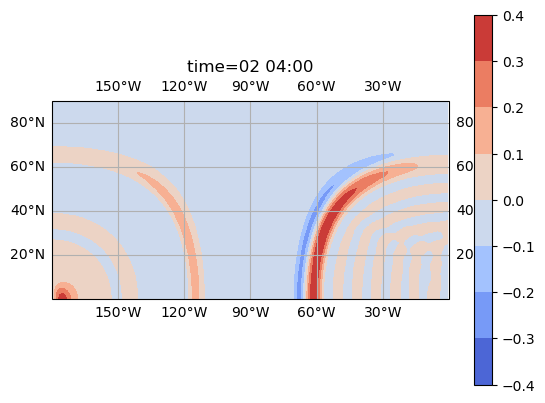

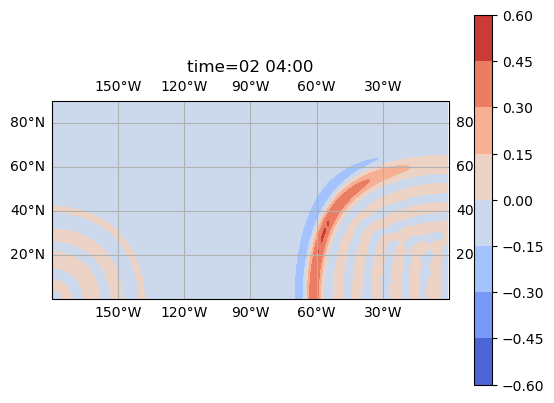

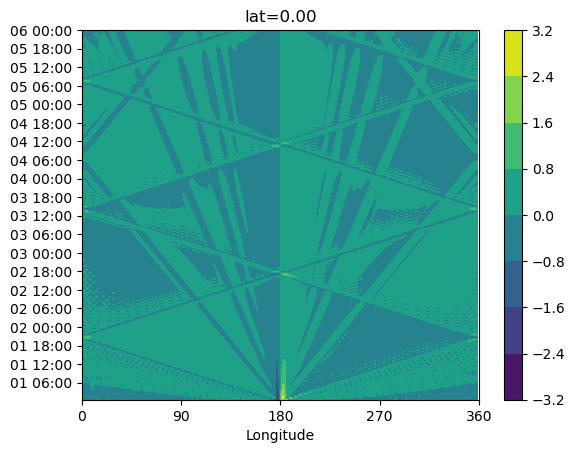

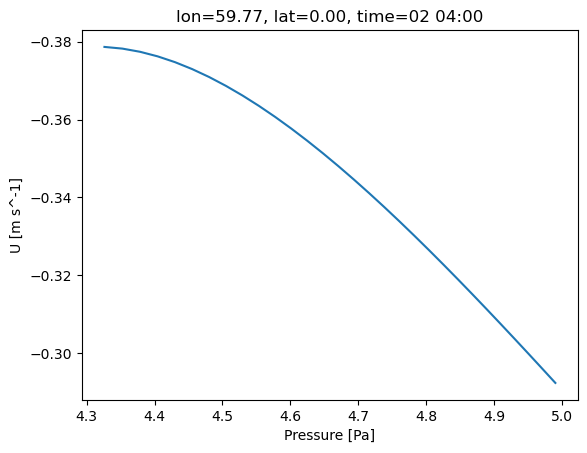

In [35]:
# plot U
projection = ccrs.PlateCarree(central_longitude=180)
# projection = ccrs.PlateCarree()
U = ds.U  # (time:180, lev: 30, lat: 257, lon: 512)
time_index = 55
level_index = -1

plt.figure(1)
ax = plt.axes(projection=projection)

LatLonPlot(ax, projection, U, time_index, level_index, 'coolwarm')

# plot U
plt.figure(2)
ax2 = plt.axes(projection=projection)

LatLonPlot(ax2, projection, U, time_index, 15, 'coolwarm')

# plot U Hovmoller
lat_value = 0

plt.figure(3)
ax3 = plt.axes(projection=None)

Hovmoller(ax3, U, level_index, lat_value, 'viridis')

# plot U cross section
lon_value = 60

plt.figure(4)
ax4 = plt.axes(projection=None)

PmidDA = xr.DataArray(Pmid, coords={'time': range(0, 240), 'lev': range(0, 30), 'lat': range(257), 'lon': range(512)}, 
                      dims=['time', 'lev', 'lat', 'lon'])

CrossSection(ax4, U, time_index, lat_value, lon_value, 'viridis')

Text(0, 0.5, 'U [m s^-1]')

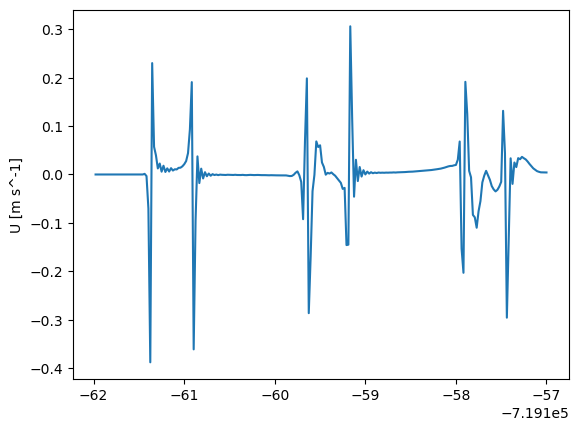

In [11]:
tstep = 30 * 60  # output time step in seconds
# datetimes = U.indexes['time'].to_datetimeindex(time_unit='s')

plt.figure(5)
ax5 = plt.axes(projection=None)

ax5.plot(date2num(U.time), U[:, -1, 128, 70])
ax5.set_ylabel('U [m s^-1]')
# locs, labels = plt.xticks()
# plt.xticks(locs, num2date(locs))
# ax5.xaxis.set_major_locator(HourLocator(interval=6))
# ax5.xaxis.set_major_formatter(DateFormatter('%d %H:%M'))

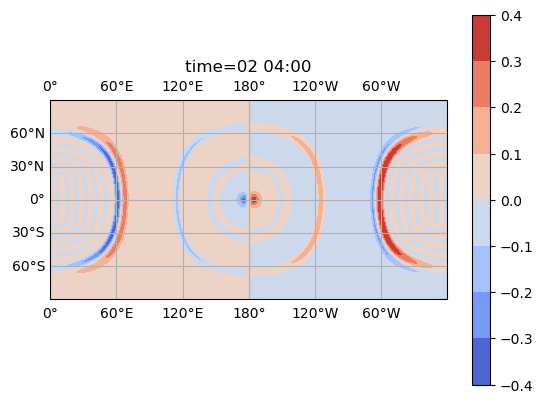

In [16]:
# plot U Hovmoller
lat_value = 0

plt.figure(5)
idek_ax = plt.axes(projection=projection)

LatLonPlot(idek_ax, projection, U, time_index, level_index, 'coolwarm')